In [1]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pickle
import pprint
import networkx as nx

import datetime as dt

#module_path = os.path.abspath(os.path.join(''))
#if module_path not in sys.path:
#    sys.path.append(module_path)

if os.path.isdir("../data/"):
    os.chdir("../")

from src.utils import *
from src.plots_utils import *
from src.transcript_matching import *
from src.file_io import *

%load_ext autoreload
%autoreload 2

rcParams, column_width, page_width, shorts_style, RV_style = get_plt_attr()
plt.rcParams.update(rcParams)

# 1. Data Loading

## 1.1 Load channel metadata

In [2]:
nm_yt_channels = pd.read_json('data/youtube/channels/news_channels.json')
pp_yt_channels = pd.read_json('data/youtube/channels/pp_channels.json')
nm_tt_channels = pd.read_json('data/tiktok/channels/news_channels.json')
pp_tt_channels = pd.read_json('data/tiktok/channels/pp_channels.json')

## 1.2 Load transcripts and videos (YouTube & TikTok)

In [3]:
politician2party = get_politician2party()

In [4]:
yt_nm_videos_2022 = pd.read_json("data/youtube/videos/news_videos_2022.jsonl", lines=True)
yt_nm_videos_2024 = pd.read_json("data/youtube/videos/news_videos_2024.jsonl", lines=True)
yt_pp_videos_2022 = pd.read_json("data/youtube/videos/pp_videos_2022.jsonl", lines=True)
yt_pp_videos_2024 = pd.read_json("data/youtube/videos/pp_videos_2024.jsonl", lines=True)
for yt_df in [yt_nm_videos_2022, yt_nm_videos_2024, yt_pp_videos_2022, yt_pp_videos_2024]:
    yt_df['publishedAt'] = pd.to_datetime(yt_df['publishedAt']).dt.tz_localize(None)
    yt_df['party'] = yt_df['name_standard'].map(politician2party)

In [5]:
videoId2yt_type = dict(zip(yt_nm_videos_2022['videoId'], ["Short"  if e==True else "RV" for e in list(yt_nm_videos_2022['isShort'])]))
videoId2yt_type.update(dict(zip(yt_nm_videos_2024['videoId'], 
                                ["Short"  if e==True else "RV" for e in list(yt_nm_videos_2024['isShort'])])))
videoId2yt_type.update(dict(zip(yt_pp_videos_2022['videoId'], 
                                ["Short"  if e==True else "RV" for e in list(yt_pp_videos_2022['isShort'])])))
videoId2yt_type.update(dict(zip(yt_pp_videos_2024['videoId'], 
                                ["Short"  if e==True else "RV" for e in list(yt_pp_videos_2024['isShort'])])))

In [6]:
videoId2publishedAt = dict(zip(yt_nm_videos_2022['videoId'], yt_nm_videos_2022['publishedAt']))
videoId2publishedAt.update(dict(zip(yt_nm_videos_2024['videoId'], yt_nm_videos_2024['publishedAt'])))
videoId2publishedAt.update(dict(zip(yt_pp_videos_2022['videoId'], yt_pp_videos_2022['publishedAt'])))
videoId2publishedAt.update(dict(zip(yt_pp_videos_2024['videoId'], yt_pp_videos_2024['publishedAt'])))

In [7]:
tt_nm_videos_2022 = pd.read_json("data/tiktok/videos/news_videos_2022.jsonl", lines=True)
tt_nm_videos_2024 = pd.read_json("data/tiktok/videos/news_videos_2024.jsonl", lines=True)
tt_pp_videos_2022 = pd.read_json("data/tiktok/videos/pp_videos_2022.jsonl", lines=True)
tt_pp_videos_2024 = pd.read_json("data/tiktok/videos/pp_videos_2024.jsonl", lines=True)
for tt_df in [tt_nm_videos_2022, tt_nm_videos_2024, tt_pp_videos_2022, tt_pp_videos_2024]:
    tt_df.rename(columns={'id':'videoId', 'voice_to_text':'transcript','create_time':'publishedAt'}, inplace=True)
    tt_df['videoId'] = tt_df['videoId'].apply(str)
    tt_df['publishedAt'] = pd.to_datetime(tt_df['publishedAt']).dt.tz_localize(None)
    tt_df['party'] = tt_df['name_standard'].map(politician2party)

In [8]:
videoId2publishedAt.update(dict(zip(tt_nm_videos_2022['videoId'], tt_nm_videos_2022['publishedAt'])))
videoId2publishedAt.update(dict(zip(tt_nm_videos_2024['videoId'], tt_nm_videos_2024['publishedAt'])))
videoId2publishedAt.update(dict(zip(tt_pp_videos_2022['videoId'], tt_pp_videos_2022['publishedAt'])))
videoId2publishedAt.update(dict(zip(tt_pp_videos_2024['videoId'], tt_pp_videos_2024['publishedAt'])))

## 1.3 Concatenate all transcripts and videos

In [9]:
all_transcripts = pd.concat([yt_nm_videos_2022[['videoId', 'transcript']], yt_nm_videos_2024[['videoId', 'transcript']],
                             yt_pp_videos_2022[['videoId', 'transcript']], yt_pp_videos_2024[['videoId', 'transcript']],
                             tt_nm_videos_2022[['videoId', 'transcript']], tt_nm_videos_2024[['videoId', 'transcript']],
                             tt_pp_videos_2022[['videoId', 'transcript']], tt_pp_videos_2024[['videoId', 'transcript']]]
                           ).dropna(subset='transcript')
all_transcripts['transcript_clean'] = all_transcripts['transcript'].apply(
    clean_transcripts,
    strip_accents=True, lowercase=True, remove_brackets=True, remove_openers=False)

Create a big dict that maps each videoId to the name of the channel (standardized)

In [10]:
videoid2standard_name = dict(zip(yt_nm_videos_2022['videoId'], yt_nm_videos_2022['name_standard']))
videoid2standard_name.update(dict(zip(yt_nm_videos_2024['videoId'], yt_nm_videos_2024['name_standard'])))
videoid2standard_name.update(dict(zip(yt_pp_videos_2022['videoId'], yt_pp_videos_2022['name_standard'])))
videoid2standard_name.update(dict(zip(yt_pp_videos_2024['videoId'], yt_pp_videos_2024['name_standard'])))
videoid2standard_name.update(dict(zip(tt_nm_videos_2022['videoId'], tt_nm_videos_2022['name_standard'])))
videoid2standard_name.update(dict(zip(tt_nm_videos_2024['videoId'], tt_nm_videos_2024['name_standard'])))
videoid2standard_name.update(dict(zip(tt_pp_videos_2022['videoId'], tt_pp_videos_2022['name_standard'])))
videoid2standard_name.update(dict(zip(tt_pp_videos_2024['videoId'], tt_pp_videos_2024['name_standard'])))

In [11]:
yt_nm_standard_names = list(nm_yt_channels.name_standard)
yt_pp_standard_names = list(pp_yt_channels.name_standard)
tt_nm_standard_names = list(nm_tt_channels.name_standard)
tt_pp_standard_names = list(pp_tt_channels.name_standard)

## 1.4 Define politician ordering

In [12]:
politician_abbr_name = get_politician_abbr_name()

# Ordered list of actors (parties + politicians) for plots — stored as abbreviated names
order_full = [
    'LFI', 'Rima Hassan', 'Manon Aubry', 'Manuel Bompard', 'Mathilde Panot',
    'Jean-Luc Mélenchon', 'François Ruffin',
    'PCF', 'EELV', 'PS', 'PP',
    'RE', 'Emmanuel Macron', 'Gabriel Attal',
    'MoDem', 'UDI', 'UPR', 'LR',
    'François Asselineau',
    'Jordan Bardella', 'Marine Le Pen',
    'Florian Philippot', 'Éric Zemmour', 'Marion Maréchal',
]

# 2. Classify Video Pairs 
## 2.1 Load Classification Model

In [13]:
with open('data/model.pkl', 'rb') as f:
    model = pickle.load(f)
with open('data/best_thr.txt') as f:
    best_thr = float(f.read())
pprint.pp(get_model_coeffs(model))
print(best_thr)

{'partialratio_cut_t1': 0.19046583676153717,
 'partialratio_cut_t2': 0.13159226421984305,
 'sortratio_cut_t1': -0.009319824971382803,
 'sortratio_cut_t2': 0.027679685960971503,
 'bias': -19.459660018321404}
0.27659622233343084


/Users/Caroline/PythonEnvs/CSS/lib/python3.14/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## 2.2 Helper function

In [14]:
def get_classified_pairs(filename, all_transcripts, model, best_thr):
    video_pairs = pd.read_csv(filename, dtype={'videoId1': str, 'videoId2': str})
    video_pairs = add_transcript_to_video_pairs(video_pairs, all_transcripts, filename)
    video_pairs = classify_pairs(video_pairs, model, best_thr)
    return video_pairs

## 2.3 YouTube pairs own reposts

In [15]:
# YOUTUBE
# 2022
#pairs_yt_same_channel_pp_2022 = get_classified_pairs(
#    filename="data/pairs_of_transcripts/pairs_same_channel_yt_pp_2022_w_d.csv",
#    all_transcripts=all_transcripts, model=model, best_thr=best_thr)

#pairs_yt_same_channel_nm_2022 = get_classified_pairs(
#    filename='data/pairs_of_transcripts/pairs_same_channel_yt_nm_2022_w_d.csv',
#    all_transcripts=all_transcripts, model=model, best_thr=best_thr)

#2024
pairs_yt_same_channel_pp_2024 = get_classified_pairs(
    filename='data/pairs_of_transcripts/pairs_yt_same_channel_pp_2024_w_d.csv',
    all_transcripts=all_transcripts, model=model, best_thr=best_thr)

pairs_yt_same_channel_nm_2024 = get_classified_pairs(
    filename='data/pairs_of_transcripts/pairs_yt_same_channel_nm_2024_w_d.csv',
    all_transcripts=all_transcripts, model=model, best_thr=best_thr)

/Users/Caroline/Documents/PhD/Research/VideosRepurposing/src/transcript_matching.py:231: UserWarning: for data/pairs_of_transcripts/pairs_yt_same_channel_nm_2024_w_d.csv, initial lenght: 4411040, curr lenght: 4411038
  warnings.warn(f"for {filename}, initial lenght: {initial_length}, curr lenght: {len(video_pairs)}")


#### save files with pairs classified as coming from the same video or not

#pairs_yt_same_channel_pp_2022.to_csv("data/pairs_of_transcripts/classified/pairs_yt_same_channel_pp_2022_classified.csv", index=False)
#pairs_yt_same_channel_nm_2022.to_csv("data/pairs_of_transcripts/classified/pairs_yt_same_channel_nm_2022_classified.csv", index=False)

pairs_yt_same_channel_pp_2024.to_csv("data/pairs_of_transcripts/classified/pairs_yt_same_channel_pp_2024_classified.csv", index=False)
pairs_yt_same_channel_nm_2024.to_csv("data/pairs_of_transcripts/classified/pairs_yt_same_channel_nm_2024_classified.csv", index=False)

## 2.4 YouTube - TikTok pairs

In [16]:
# TikTok
# 2022
#pairs_same_actor_yt_tt_pp_2022 = get_classified_pairs(
#    filename="data/pairs_of_transcripts/pairs_same_actor_yt_tt_pp_2022_w_d.csv",
#    all_transcripts=all_transcripts, model=model, best_thr=best_thr)

#pairs_same_party_yt_tt_2022 = get_classified_pairs(
#    filename="data/pairs_of_transcripts/pairs_same_party_yt_tt_2022_w_d.csv",
#    all_transcripts=all_transcripts, model=model, best_thr=best_thr)

#pairs_same_actor_yt_tt_nm_2022 = get_classified_pairs(
#    filename='data/pairs_of_transcripts/pairs_same_actor_yt_tt_nm_2022_w_d.csv',
#    all_transcripts=all_transcripts, model=model, best_thr=best_thr)

#2024
pairs_same_actor_yt_tt_pp_2024 = get_classified_pairs(
    filename="data/pairs_of_transcripts/pairs_same_actor_yt_tt_pp_2024_w_d.csv",
    all_transcripts=all_transcripts, model=model, best_thr=best_thr)

pairs_same_party_yt_tt_2024 = get_classified_pairs(
    filename='data/pairs_of_transcripts/pairs_same_party_yt_tt_2024_w_d.csv',
    all_transcripts=all_transcripts, model=model, best_thr=best_thr)

pairs_same_actor_yt_tt_nm_2024 = get_classified_pairs(
    filename='data/pairs_of_transcripts/pairs_same_actor_yt_tt_nm_2024_w_d.csv',
    all_transcripts=all_transcripts, model=model, best_thr=best_thr)

#pairs_same_actor_yt_tt_pp_2022.to_csv("data/pairs_of_transcripts/classified/pairs_same_actor_yt_tt_pp_2022_classified.csv", index=False)
#pairs_same_party_yt_tt_2022.to_csv("data/pairs_of_transcripts/classified/pairs_same_party_yt_tt_2022_classified.csv", index=False)
#pairs_same_actor_yt_tt_nm_2022.to_csv("data/pairs_of_transcripts/classified/pairs_same_actor_yt_tt_nm_2022_classified.csv", index=False)

pairs_same_actor_yt_tt_pp_2024.to_csv("data/pairs_of_transcripts/classified/pairs_same_actor_yt_tt_pp_2024_classified.csv", index=False)
pairs_same_party_yt_tt_2024.to_csv("data/pairs_of_transcripts/classified/pairs_same_party_yt_tt_2024_classified.csv", index=False)
pairs_same_actor_yt_tt_nm_2024.to_csv("data/pairs_of_transcripts/classified/pairs_same_actor_yt_tt_nm_2024_classified.csv", index=False)

# Repost between PP and NM

In [17]:
# 2022 
#pairs_diff_channels_yt_2022 = get_classified_pairs(
#    filename='data/pairs_of_transcripts/pairs_diff_channels_yt_pp_all_nm_2022_w_d.csv',
#    all_transcripts=all_transcripts, model=model, best_thr=best_thr)

# 2024
pairs_diff_channels_yt_pp_2024 = get_classified_pairs(
    filename='data/pairs_of_transcripts/pairs_diff_channels_yt_pp_all_nm_2024_w_d.csv',
    all_transcripts=all_transcripts, model=model, best_thr=best_thr)

pairs_diff_channels_yt_party_2024 = get_classified_pairs(
    filename='data/pairs_of_transcripts/pairs_diff_channels_yt_party_all_nm_2024_w_d.csv',
    all_transcripts=all_transcripts, model=model, best_thr=best_thr)


pairs_diff_channels_tt_pp_2024  = get_classified_pairs(
    filename='data/pairs_of_transcripts/pairs_diff_channels_tt_pp_all_nm_2024_w_d.csv',
    all_transcripts=all_transcripts, model=model, best_thr=best_thr)

pairs_diff_channels_tt_party_2024 = get_classified_pairs(
    filename='data/pairs_of_transcripts/pairs_diff_channels_tt_party_all_nm_2024_w_d.csv',
    all_transcripts=all_transcripts, model=model, best_thr=best_thr)

#### save files with pairs classified as coming from the same video or not

#pairs_diff_channels_yt_2022.to_csv("data/pairs_of_transcripts/classified/pairs_diff_channels_yt_pp_all_nm_2022_classified.csv", index=False)
pairs_diff_channels_yt_pp_2024.to_csv("data/pairs_of_transcripts/classified/pairs_diff_channels_yt_pp_all_nm_2024_classified.csv", index=False)
pairs_diff_channels_yt_party_2024.to_csv("data/pairs_of_transcripts/classified/pairs_diff_channels_yt_party_all_nm_2024_classified.csv", index=False)

pairs_diff_channels_tt_pp_2024.to_csv("data/pairs_of_transcripts/classified/pairs_diff_channels_tt_pp_all_nm_2024_classified.csv", index=False)
pairs_diff_channels_tt_party_2024.to_csv("data/pairs_of_transcripts/classified/pairs_diff_channels_tt_party_all_nm_2024_classified.csv", index=False)

# 3. Classification Sanity Check

Distribution of predicted probabilities across all pairs, with decision boundary τ.

In [18]:
predicted_probas = list(pairs_yt_same_channel_pp_2024.predicted_proba) + \
                    list(pairs_yt_same_channel_nm_2024.predicted_proba) + \
                    list(pairs_same_actor_yt_tt_pp_2024.predicted_proba) + \
                    list(pairs_same_party_yt_tt_2024.predicted_proba) + \
                    list(pairs_same_actor_yt_tt_nm_2024.predicted_proba) + \
                    list(pairs_diff_channels_yt_pp_2024.predicted_proba) + \
                    list(pairs_diff_channels_tt_pp_2024.predicted_proba)

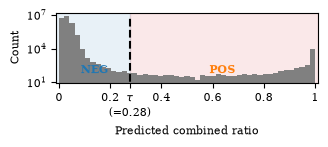

In [19]:
fig, ax = plt.subplots(figsize= (column_width, 1.5))

bin_edges = np.linspace(0, 1, 50)
# shaded region for predicted negative side
ax.axvspan(-0.01, best_thr, color="tab:blue", alpha=0.1)

# shaded region for predicted positive side
ax.axvspan(best_thr, 1.01, color="tab:red", alpha=0.1)
ax.hist(sorted(predicted_probas), bins = bin_edges, color = 'grey')

ax.plot([best_thr, best_thr], ax.get_ylim(), '--', color='k')

ax.set_xlabel('Predicted combined ratio')
ax.set_ylabel("Count")
ax.set_yscale('log')
ax.set_xlim(-0.01, 1.01)
ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1, best_thr], ['0', '0.2', '0.4', '0.6', '0.8', '1', r'$\tau$' + f'\n(={best_thr:.2f})'])
ax.set_xticklabels(ax.get_xticklabels())
ax.text(best_thr/2, 65, 'NEG', color='tab:blue', fontdict={'fontweight':'bold'}, ha='center')
ax.text(best_thr+(1-best_thr)/2, 65, 'POS', color='tab:orange', fontdict={'fontweight':'bold'}, ha='center')
plt.tight_layout()
#fig.savefig('figures_shortpaper_WWW/decision_boundary_plot.pdf')

# 4. Build Similarity Graphs and Channel Mappings

For each channel, construct a graph where nodes are videos and edges connect pairs classified as matches (predicted_label == 1). These graphs are used downstream to look up the source video for a given repost.

## 4.1 Adding name_standard and party to pairs of transcripts

In [20]:
def add_name_standard_to_transcript_pairs(pairs_df, same_channel = True, w_tt = False):
    init_length = len(pairs_df)
    if same_channel:
        assert w_tt == False, "same_channel and w_tt (with tiktok) can't be true at the same time)"
        
        pairs_df['name_standard'] = pairs_df['videoId1'].map(videoid2standard_name)
        pairs_df['party'] = pairs_df['name_standard'].apply(lambda x: politician2party.get(x, None))
        if len(pairs_df[pairs_df['party'].isna()]) == len(pairs_df):
            pairs_df.drop(columns = ['party'], inplace=True)
    else:
        if w_tt:
            pairs_df['tt_name_standard'] = pairs_df['videoId1'].map(videoid2standard_name)
            pairs_df['yt_name_standard'] = pairs_df['videoId2'].map(videoid2standard_name)
            pairs_df['party'] = pairs_df['tt_name_standard'].apply(lambda x: politician2party.get(x, None))
            # If all party is na, it means that its news pairs 
            if len(pairs_df[pairs_df['party'].isna()]) == len(pairs_df):
                pairs_df.drop(columns = ['party'], inplace=True)
                
        else:
            pairs_df['name_standard1'] = pairs_df['videoId1'].map(videoid2standard_name)
            pairs_df['name_standard2'] = pairs_df['videoId2'].map(videoid2standard_name)
    assert len(pairs_df) == init_length
    return pairs_df

In [21]:
pairs_yt_same_channel_pp_2024 = add_name_standard_to_transcript_pairs(pairs_yt_same_channel_pp_2024)
pairs_yt_same_channel_nm_2024 = add_name_standard_to_transcript_pairs(pairs_yt_same_channel_nm_2024)

In [22]:
pairs_same_actor_yt_tt_pp_2024 = add_name_standard_to_transcript_pairs(pairs_same_actor_yt_tt_pp_2024, same_channel = False, w_tt = True)
pairs_same_party_yt_tt_2024 = add_name_standard_to_transcript_pairs(pairs_same_party_yt_tt_2024, same_channel = False, w_tt = True)
pairs_same_actor_yt_tt_nm_2024 = add_name_standard_to_transcript_pairs(pairs_same_actor_yt_tt_nm_2024, same_channel = False, w_tt = True)

In [23]:
pairs_diff_channels_yt_2024 = add_name_standard_to_transcript_pairs(pd.concat([pairs_diff_channels_yt_pp_2024,
                                                                               pairs_diff_channels_yt_party_2024]), same_channel = False)
pairs_diff_channels_tt_2024 = add_name_standard_to_transcript_pairs(pd.concat([pairs_diff_channels_tt_pp_2024,
                                                                               pairs_diff_channels_tt_party_2024]), same_channel = False)

## 4.2 Similarity graphs: within-politician pairs (`gs_pp_only`)

In [24]:
gs_pp_only = dict()
for name_standard in yt_pp_standard_names:
    pairs_df_curr = pairs_yt_same_channel_pp_2024[pairs_yt_same_channel_pp_2024.name_standard == name_standard]
    
    gs_pp_only[name_standard] = nx.Graph()
    yt_nodes = set(pairs_df_curr.videoId1).union(set(pairs_df_curr.videoId2))
    shorts_nodes = [v for v in list(yt_nodes) if videoId2yt_type[v] == "Short"]
    RV_nodes = [v for v in list(yt_nodes) if videoId2yt_type[v] == "RV"]
    gs_pp_only[name_standard].add_nodes_from(shorts_nodes, type = 'Short')
    gs_pp_only[name_standard].add_nodes_from(RV_nodes, type = 'RV')
    
    for v1, v2 in zip(pairs_df_curr[pairs_df_curr.predicted_label == 1].videoId1, 
                      pairs_df_curr[pairs_df_curr.predicted_label == 1].videoId2):
        publishedAt1 = videoId2publishedAt[v1]
        publishedAt2 = videoId2publishedAt[v2]
        elapsed_time = np.absolute(publishedAt2 - publishedAt1)
        elapsed_time_sec = elapsed_time.total_seconds()
        if publishedAt1 < publishedAt2: first_node = v1
        else: first_node = v2
        gs_pp_only[name_standard].add_edge(v1, v2, elapsed_time=elapsed_time, elapsed_time_sec = elapsed_time_sec, first_node = first_node)
        
    if name_standard in tt_pp_standard_names:
        pairs_yt_tt_curr = pairs_same_party_yt_tt_2024[
        (pairs_same_party_yt_tt_2024.yt_name_standard == name_standard) & (pairs_same_party_yt_tt_2024.tt_name_standard == name_standard)]
        gs_pp_only[name_standard].add_nodes_from(set(pairs_yt_tt_curr.videoId1), type = 'tiktok')
        
        for v1, v2 in zip(pairs_yt_tt_curr[pairs_yt_tt_curr.predicted_label == 1].videoId1, 
                          pairs_yt_tt_curr[pairs_yt_tt_curr.predicted_label == 1].videoId2):
            publishedAt1 = videoId2publishedAt[v1]
            publishedAt2 = videoId2publishedAt[v2]
            elapsed_time = np.absolute(publishedAt2 - publishedAt1)
            elapsed_time_sec = elapsed_time.total_seconds()
            if publishedAt1 < publishedAt2: first_node = v1
            else: first_node = v2
            gs_pp_only[name_standard].add_edge(v1, v2, elapsed_time=elapsed_time, elapsed_time_sec = elapsed_time_sec, first_node = first_node)

In [25]:
for name_standard in gs_pp_only.keys():
    nx.nx_agraph.write_dot(gs_pp_only[name_standard], f'data/networks/pp_only_2024/{name_standard}_gs_pp_only_2024.gv')

## 4.3 Similarity graphs: within-news pairs (`gs_news_only`)

In [26]:
gs_news_only = dict()
for name_standard in yt_nm_standard_names:
    pairs_df_curr = pairs_yt_same_channel_nm_2024[pairs_yt_same_channel_nm_2024.name_standard == name_standard]
    gs_news_only[name_standard] = nx.Graph()

    yt_nodes = set(pairs_df_curr.videoId1).union(set(pairs_df_curr.videoId2))
    shorts_nodes = [v for v in list(yt_nodes) if videoId2yt_type[v] == "Short"]
    RV_nodes = [v for v in list(yt_nodes) if videoId2yt_type[v] == "RV"]
    gs_news_only[name_standard].add_nodes_from(shorts_nodes, type = 'Short')
    gs_news_only[name_standard].add_nodes_from(RV_nodes, type = 'RV')

    for v1, v2 in zip(pairs_df_curr[pairs_df_curr.predicted_label == 1].videoId1,
                      pairs_df_curr[pairs_df_curr.predicted_label == 1].videoId2):
        publishedAt1 = videoId2publishedAt[v1]
        publishedAt2 = videoId2publishedAt[v2]
        elapsed_time = np.absolute(publishedAt2 - publishedAt1)
        elapsed_time_sec = elapsed_time.total_seconds()
        if publishedAt1 < publishedAt2: first_node = v1
        else: first_node = v2
        gs_news_only[name_standard].add_edge(v1, v2, elapsed_time=elapsed_time, elapsed_time_sec = elapsed_time_sec, first_node = first_node)

    if name_standard in tt_nm_standard_names:
        pairs_yt_tt_curr = pairs_same_actor_yt_tt_nm_2024[
        (pairs_same_actor_yt_tt_nm_2024.yt_name_standard == name_standard) & (pairs_same_actor_yt_tt_nm_2024.tt_name_standard == name_standard)]
        gs_news_only[name_standard].add_nodes_from(set(pairs_yt_tt_curr.videoId1), type = 'tiktok')

        for v1, v2 in zip(pairs_yt_tt_curr[pairs_yt_tt_curr.predicted_label == 1].videoId1,
                          pairs_yt_tt_curr[pairs_yt_tt_curr.predicted_label == 1].videoId2):
            publishedAt1 = videoId2publishedAt[v1]
            publishedAt2 = videoId2publishedAt[v2]
            elapsed_time = np.absolute(publishedAt2 - publishedAt1)
            elapsed_time_sec = elapsed_time.total_seconds()
            if publishedAt1 < publishedAt2: first_node = v1
            else: first_node = v2
            gs_news_only[name_standard].add_edge(v1, v2, elapsed_time=elapsed_time, elapsed_time_sec = elapsed_time_sec, first_node = first_node)

In [27]:
for name_standard in gs_news_only.keys():
    nx.nx_agraph.write_dot(gs_news_only[name_standard], f'data/networks/news_only_2024/{name_standard}_gs_news_only_2024.gv')

## 4.4 Similarity graphs: cross-channel pairs — politician/parties vs. news (`gs_diff`)

In [28]:
gs_diff = dict()

for name_standard in yt_pp_standard_names:
    # one is with politicians and one is for parties
    pairs_df_curr = pairs_diff_channels_yt_2024[pairs_diff_channels_yt_2024.name_standard1 == name_standard]
    gs_diff[name_standard] = nx.Graph()
    gs_diff[name_standard].add_nodes_from(set(pairs_df_curr.videoId1), type = 'youtube_pp')
    gs_diff[name_standard].add_nodes_from(set(pairs_df_curr.videoId2), type = 'nm')


    for v1, v2 in zip(pairs_df_curr[pairs_df_curr.predicted_label == 1].videoId1,
                      pairs_df_curr[pairs_df_curr.predicted_label == 1].videoId2):
        publishedAt1 = videoId2publishedAt[v1]
        publishedAt2 = videoId2publishedAt[v2]
        elapsed_time = np.absolute(publishedAt2 - publishedAt1)
        elapsed_time_sec = elapsed_time.total_seconds()
        if publishedAt1 < publishedAt2: first_node = v1
        else: first_node = v2
        gs_diff[name_standard].add_edge(v1, v2, elapsed_time=elapsed_time, elapsed_time_sec = elapsed_time_sec, first_node = first_node)
    
    if name_standard in tt_pp_standard_names:
        pairs_df_tt_curr = pairs_diff_channels_tt_2024[pairs_diff_channels_tt_2024.name_standard1 == name_standard]
        gs_diff[name_standard].add_nodes_from(set(pairs_df_tt_curr.videoId1), type = 'tiktok_pp')
        gs_diff[name_standard].add_nodes_from(set(pairs_df_tt_curr.videoId2), type = 'nm')

        for v1, v2 in zip(pairs_df_tt_curr[pairs_df_tt_curr.predicted_label == 1].videoId1,
                          pairs_df_tt_curr[pairs_df_tt_curr.predicted_label == 1].videoId2):
            publishedAt1 = videoId2publishedAt[v1]
            publishedAt2 = videoId2publishedAt[v2]
            elapsed_time = np.absolute(publishedAt2 - publishedAt1)
            elapsed_time_sec = elapsed_time.total_seconds()
            if publishedAt1 < publishedAt2: first_node = v1
            else: first_node = v2
            gs_diff[name_standard].add_edge(v1, v2, elapsed_time=elapsed_time, elapsed_time_sec = elapsed_time_sec, first_node = first_node) 

In [29]:
for name_standard in gs_diff.keys():
    nx.nx_agraph.write_dot(gs_diff[name_standard], f'data/networks/diff_2024/{name_standard}_gs_diff_2024.gv')

## 4.5 Similarity graph among party members

In [30]:
parties = pairs_same_party_yt_tt_2024.party.unique()

In [31]:
gs_parties = dict()
for party in parties:
    # filter yt pairs to keep only those where party is current party
    pairs_yt_curr = pairs_yt_same_channel_pp_2024[pairs_yt_same_channel_pp_2024.party == party]
    
    gs_parties[party] = nx.Graph()
    gs_parties[party].add_nodes_from(set(pairs_yt_curr.videoId1), type = "Short")
    gs_parties[party].add_nodes_from(set(pairs_yt_curr.videoId2), type = "RV")
    
    gs_parties[party].add_edges_from([(v1, v2) for v1, v2 in 
                                     zip(pairs_yt_curr[pairs_yt_curr.predicted_label == 1].videoId1, 
                                         pairs_yt_curr[pairs_yt_curr.predicted_label == 1].videoId2)])

    # filter yt_tt pairs to keep only those where party is current party
    pairs_yt_tt_curr = pairs_same_party_yt_tt_2024[pairs_same_party_yt_tt_2024.party == party]
    
    gs_parties[party].add_nodes_from(set(pairs_yt_tt_curr.videoId1), type = 'tiktok')
    gs_parties[party].add_edges_from([(v1, v2) for v1, v2 in 
                                     zip(pairs_yt_tt_curr[pairs_yt_tt_curr.predicted_label == 1].videoId1, 
                                         pairs_yt_tt_curr[pairs_yt_tt_curr.predicted_label == 1].videoId2)])
    # RVs are complicated to count: if there is 0 shorts there won't be a pair in pairs_yt_curr and RVs number would be set to zero 
    # so it's RVs from yt_pairs ⋃ videos from yt_tt_pairs - shorts from yt_pairs
    print(f"{party} - {len(set(pairs_yt_curr.videoId1))} Shorts - \
{len(set(pairs_yt_curr.videoId2).union(set(pairs_yt_tt_curr.videoId2)).difference(set(pairs_yt_curr.videoId1)))} RVs - \
{len(set(pairs_yt_tt_curr.videoId1))} tiktoks") 
    print(f"\t {len(gs_parties[party].nodes)} nodes and {len(gs_parties[party].edges)} edges")

REC - 41 Shorts - 98 RVs - 200 tiktoks
	 339 nodes and 160 edges


RN - 291 Shorts - 86 RVs - 765 tiktoks
	 1142 nodes and 462 edges
LR - 0 Shorts - 11 RVs - 114 tiktoks
	 116 nodes and 2 edges
RE - 11 Shorts - 22 RVs - 318 tiktoks
	 350 nodes and 37 edges
PP - 22 Shorts - 168 RVs - 5 tiktoks
	 195 nodes and 3 edges


PS - 6 Shorts - 71 RVs - 52 tiktoks
	 129 nodes and 12 edges
EELV - 1 Shorts - 96 RVs - 168 tiktoks
	 265 nodes and 67 edges


LFI - 184 Shorts - 403 RVs - 1127 tiktoks
	 1714 nodes and 633 edges
PCF - 149 Shorts - 153 RVs - 258 tiktoks
	 560 nodes and 384 edges
NPA - 1 Shorts - 75 RVs - 44 tiktoks
	 120 nodes and 22 edges


LO - 0 Shorts - 39 RVs - 103 tiktoks
	 107 nodes and 6 edges
DLF - 69 Shorts - 36 RVs - 104 tiktoks
	 209 nodes and 86 edges
LP - 4 Shorts - 157 RVs - 65 tiktoks
	 221 nodes and 21 edges
UPR - 23 Shorts - 113 RVs - 191 tiktoks
	 327 nodes and 49 edges


In [32]:
for name_standard in gs_parties.keys():
    nx.nx_agraph.write_dot(gs_parties[name_standard], f'data/networks/parties_2024/{name_standard}_gs_parties_2024.gv')

## 4.6 Helper: look up source video for a given video

In [33]:
# I do remember that for some cases I had to take it when it's larger than 1 but now it seems absurd to do so because when there is only one link it disappears
def get_source(row, name_standard, gs):
    try:
        videoId = row.videoId.values[0]
    except AttributeError as e:
        videoId = row.videoId
    if videoId in gs[name_standard]:
        #print(gs[name_standard][videoId])
        if len(list(gs[name_standard][videoId])) > 0:
            return list(gs[name_standard][videoId])
        else :
            return ''
    else: 
        return ''

# 5. Upload Pattern Visualisations

Timeline scatter plots showing when Regular Videos (RVs) and Shorts were posted, with lines connecting matched pairs.

## 5.1 Politician channels — within-channel matches (Shorts extracted from own RVs and TikTok posting)

In [34]:
politicians_yt_channelT = ['Jean-Luc Mélenchon', 'Mathilde Panot', 'Manon Aubry', 'Manuel Bompard', 'Rima Hassan',
                           'François Ruffin',
                           'Emmanuel Macron', 'Gabriel Attal',
                           'François Asselineau', 
                           'Nicolas Dupont-Aignan',
                           'Marine Le Pen', 'Jordan Bardella',
                           'Florian Philippot',
                           'Éric Zemmour', 'Marion Maréchal']

parties_yt_channelT = ['LO','NPA', 'LFI', 'PCF', 'EELV', 'PS', 'PP', 'UDI', 'RE', 'MoDem', 'LR', 'UPR', 'RN','LP',]

assert set(politicians_yt_channelT+parties_yt_channelT) == set(yt_pp_standard_names), \
f"set politicians and parties : {set(politicians_yt_channelT+parties_yt_channelT)}\nset yt_pp_standard names : {set(yt_pp_standard_names)}"


In [35]:
heads_of_party = ['Jean-Luc Mélenchon',
 'Emmanuel Macron',
 'Jordan Bardella']

In [36]:
def plot_upload_patterns(df_yt_all, df_tt_all, gs, channels_list = None, save_fig = None, parties_all_members = False):
    
    if not channels_list:
        channels_list = list(df_yt_all.name_standard.unique())
    
    fig, axes = plt.subplots(len(channels_list), 1, 
                         figsize=(column_width, len(channels_list)*0.75), sharex=True)
    
    x0 = None
    y_position_RVs = 0.1
    y_position_Shorts_bot = 0.89
    y_position_Shorts_top = 1.1
    y_position_TikTok = 1.9
    
    for i, name_standard in enumerate(channels_list):
        ax = axes[i]
        
        if parties_all_members: filter_col = 'party'
        else: filter_col = 'name_standard'
            
        df_yt = df_yt_all[df_yt_all[filter_col] == name_standard]
        
        df_yt['type'] = df_yt['isShort'].apply(lambda x: 'S' if x else 'RV')
        df_yt['publishedAt'] = df_yt['publishedAt'].dt.tz_localize(None)
        
        df_yt_w_tr = df_yt[~(df_yt.transcript.isna()) & (df_yt.transcript != '') ]
        df_yt_wo_tr = df_yt[(df_yt.transcript.isna()) | (df_yt.transcript == '')]
        
        df_yt_w_tr.loc[df_yt_w_tr.type == 'S', 'source_videoId_yt'] = df_yt_w_tr.loc[df_yt_w_tr.type == 'S'].apply(
            get_source, name_standard=name_standard, gs=gs, axis=1)
        
        
        df_tt = df_tt_all[df_tt_all[filter_col] == name_standard][['videoId', 'publishedAt']]
            
        df_tt['source_videoId_tt'] = df_tt.apply(
            get_source, name_standard=name_standard, gs=gs, axis=1, result_type='reduce')
        
        df_tt['type'] = 'TT'
        df_tt['publishedAt'] = df_tt['publishedAt'].dt.tz_localize(None)
        
        df = pd.concat([df_yt_w_tr, df_tt])
        
        s = 10
        for video_type in ['RV', 'S', 'TT']:
            ax.scatter(
                x=df[df['type'] == video_type]['publishedAt'],
                y=df[df['type'] == video_type]['type'],
                s=s, edgecolors='k', linewidth=0.5
            )
            # if no Rv, no Short, or no TikTok, put an invisible point so that the label appear on the figure at the right position
            if len(df[df['type'] == video_type]) == 0:
                
                ax.scatter(
                x=dt.datetime.strptime('2024-05-15 19:05:00',
                     '%Y-%m-%d %H:%M:%S'),
                y=video_type,
                s=s, edgecolors='w', color = 'w', linewidth=0.5
            )
                
        for video_type in ['RV', 'S']:
            ax.scatter(
                x=df_yt_wo_tr[df_yt_wo_tr['type'] == video_type]['publishedAt'],
                y=df_yt_wo_tr[df_yt_wo_tr['type'] == video_type]['type'],
                s=s, edgecolors='grey', color='lightgrey', linewidth=0.5
            )
        
        # Lines: video match between short and RV
        for _, row in df_yt_w_tr.dropna(subset=['source_videoId_yt']).iterrows():
            for source_video in row['source_videoId_yt']:
                src_time = df_yt_w_tr.loc[df_yt_w_tr['videoId'] == source_video, 'publishedAt'].values
                if len(src_time):
                    ax.plot([src_time[0], row['publishedAt']], 
                            [y_position_RVs, y_position_Shorts_bot], color='k', linewidth=0.4)
        
        # Lines: video match between youtube and tiktok
        for _, row in df_tt.dropna(subset=['source_videoId_tt']).iterrows():
            source_videos = row['source_videoId_tt']
            
            # Check if there's a Short among the sources
            short_sources = [sv for sv in source_videos 
                             if sv in df_yt_w_tr['videoId'].values 
                             and df_yt_w_tr.loc[df_yt_w_tr['videoId'] == sv, 'type'].values[0] == 'S']
            
            # Collect RVs that are already linked to one of those Shorts (via source_videoId_yt)
            rvs_covered_by_shorts = set()
            for short_id in short_sources:
                short_row = df_yt_w_tr.loc[df_yt_w_tr['videoId'] == short_id]
                if len(short_row) and len(short_row.iloc[0].get('source_videoId_yt')) > 0:
                    for rv in short_row.iloc[0]['source_videoId_yt']:
                        rvs_covered_by_shorts.add(rv)
            
            for source_video in source_videos:
                yt_video_row = df_yt_w_tr.loc[df_yt_w_tr['videoId'] == source_video]
                if len(yt_video_row):
                    source_video_type = yt_video_row['type'].values[0]
                    source_time = yt_video_row['publishedAt'].values[0]
                    if source_video_type == 'RV':
                        # Skip this RV→TikTok line if the RV is already covered via a Short
                        if source_video in rvs_covered_by_shorts:
                            continue
                        ax.plot([source_time, row['publishedAt']], 
                                [y_position_RVs, y_position_TikTok], color='b', linewidth=0.4)
                    elif source_video_type == 'S':
                        ax.plot([source_time, row['publishedAt']], 
                                [y_position_Shorts_top, y_position_TikTok], color='b', linewidth=0.4)
                    else:
                        raise ValueError(yt_video_row['type'])
    
    
        ax.set_ylim(-0.5, 3.2)
        ax.set_xticks(['2024-03-01', '2024-03-15', '2024-04-01', '2024-04-15', '2024-05-01',
                       '2024-05-15', '2024-06-01', '2024-06-15', '2024-07-01', '2024-07-15'])
        ax.set_xticklabels(['1-03', '15-03', '1-04', '15-04', '1-05',
                            '15-05', '1-06', '15-06', '1-07', '15-07'],
                           rotation=45, ha='right', rotation_mode='anchor')
        if x0 is None:
            x0, _ = ax.get_xlim()
        ax.text(x0 + 2, 2.5, name_standard)
        
        
        #ax.set_ylim(-0.5, 1.5)
    plt.tight_layout(pad=1.5, w_pad=0, h_pad=0)
    if save_fig:
        plt.savefig(save_fig, bbox_inches='tight')

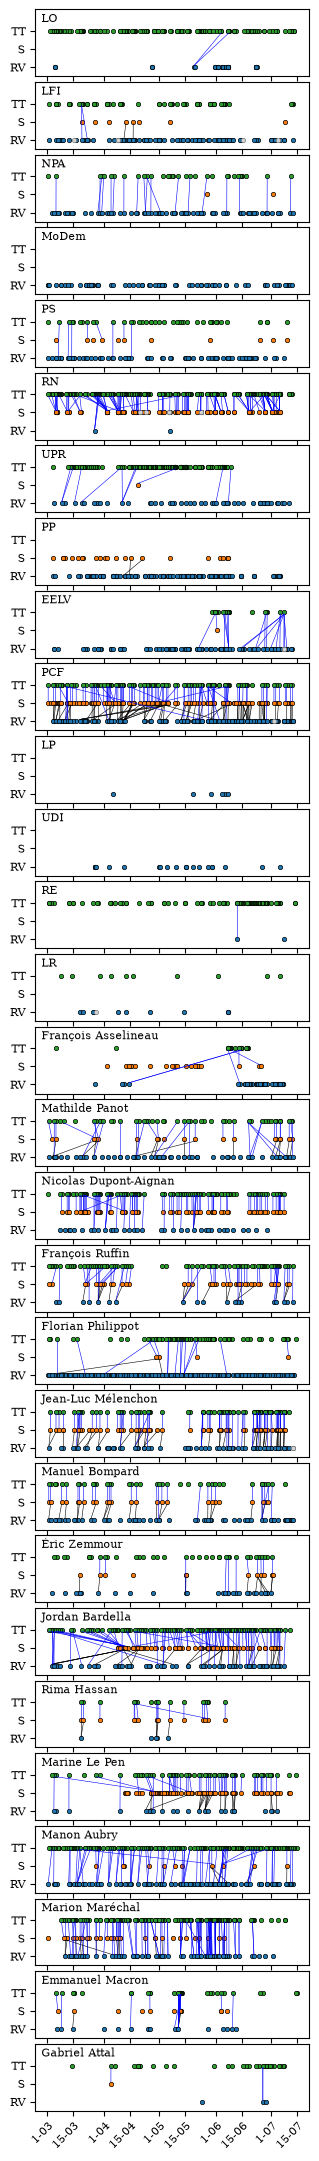

In [37]:
plot_upload_patterns(df_yt_all = yt_pp_videos_2024, df_tt_all = tt_pp_videos_2024, gs = gs_pp_only, 
                     save_fig = f'Figures/upload_patterns_pp.pdf')

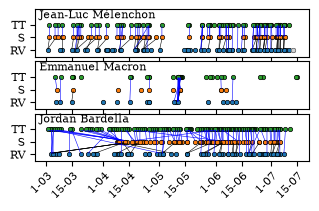

In [38]:
plot_upload_patterns(df_yt_all = yt_pp_videos_2024, df_tt_all = tt_pp_videos_2024, gs = gs_pp_only, 
                     channels_list = heads_of_party, save_fig = f'Figures/upload_patterns_heads_parties.pdf')

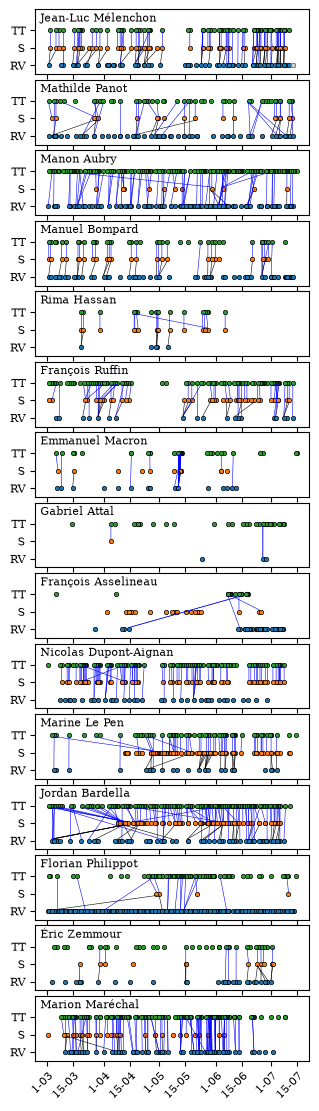

In [55]:
plot_upload_patterns(df_yt_all = yt_pp_videos_2024, df_tt_all = tt_pp_videos_2024, gs = gs_pp_only, 
                     channels_list = politicians_yt_channelT, save_fig = f'Figures/upload_patterns_polit.pdf')

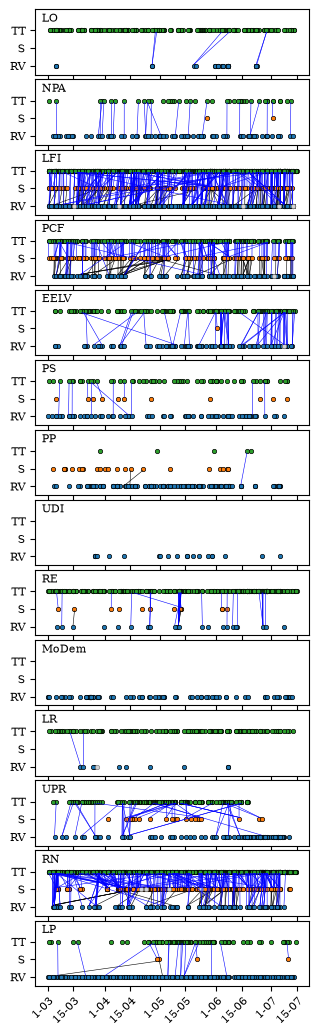

In [56]:
plot_upload_patterns(df_yt_all = yt_pp_videos_2024, df_tt_all = tt_pp_videos_2024, gs = gs_parties, 
                     channels_list = parties_yt_channelT, save_fig = f'Figures/upload_patterns_parties.pdf', parties_all_members = True)

## 6.2 News channels — within-channel matches (Shorts extracted from own RVs)

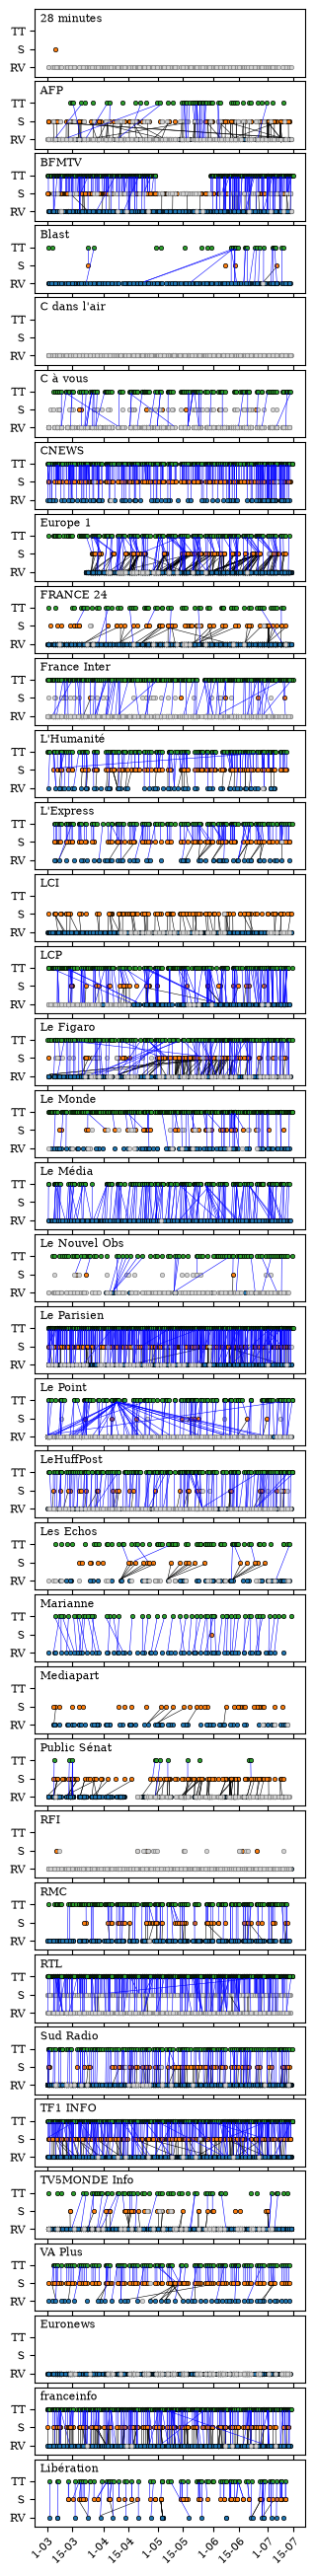

In [57]:
plot_upload_patterns(df_yt_all = yt_nm_videos_2024, df_tt_all = tt_nm_videos_2024, gs = gs_news_only, 
                     channels_list = yt_nm_standard_names, save_fig = f'Figures/upload_patterns_nm.pdf')

## 6.3 cross-channel matches (politician vs. news)

In [58]:
def plot_upload_patterns_news_pp(df_yt_all, df_tt_all, gs, df_news_all, gs_news=None, channels_list=None,
                         save_fig=None, parties_all_members=False,
                         news_flag_col=None):

    if gs_news is None:
        gs_news = gs  # fall back to single graph if no separate news graph given

    if not channels_list:
        channels_list = list(df_yt_all.name_standard.unique())

    fig, axes = plt.subplots(len(channels_list), 1,
                             figsize=(column_width, len(channels_list)), sharex=True)

    x0 = None

    y_position_News = 0.1
    y_position_RVs_bot = 0.89
    y_position_RVs_top = 1.1
    y_position_Shorts_bot = 1.89
    y_position_Shorts_top = 2.1
    y_position_TikTok = 2.9

    for i, name_standard in enumerate(channels_list):
        ax = axes[i]

        if parties_all_members:
            filter_col = 'party'
        else:
            filter_col = 'name_standard'

        df_yt = df_yt_all[df_yt_all[filter_col] == name_standard]

        df_yt['type'] = df_yt['isShort'].apply(lambda x: 'S' if x else 'RV')
        df_yt['publishedAt'] = df_yt['publishedAt'].dt.tz_localize(None)

        df_yt_w_tr = df_yt[~(df_yt.transcript.isna()) & (df_yt.transcript != '')]
        df_yt_wo_tr = df_yt[(df_yt.transcript.isna()) | (df_yt.transcript == '')]

        df_yt_w_tr.loc[df_yt_w_tr.type == 'S', 'source_videoId_yt'] = df_yt_w_tr.loc[df_yt_w_tr.type == 'S'].apply(
            get_source, name_standard=name_standard, gs=gs, axis=1)
        
            # --- News videos mentioning this channel (from df_yt_all via boolean column) ---
        if name_standard in df_news_all.columns:
            df_news = df_news_all[
                (df_news_all[name_standard] == True) &
                (~(df_news_all.transcript.isna()) & (df_news_all.transcript != ''))
            ][['videoId', 'isShort', 'publishedAt', 'transcript']].copy()
        else:
            # no news column for this channel -> empty frame with expected cols
            df_news = df_news_all.iloc[0:0][['videoId', 'isShort', 'publishedAt', 'transcript']].copy()

        df_news['type'] = 'News'
        if len(df_news):
            df_news['publishedAt'] = df_news['publishedAt'].dt.tz_localize(None)

        # For each politician video with transcript, find its news source(s) (list-valued)
        df_yt_w_tr['source_videoId_news'] = df_yt_w_tr.apply(
            get_source, name_standard=name_standard, gs=gs_news, axis=1)

        # --- TikTok ---
        df_tt = df_tt_all[df_tt_all[filter_col] == name_standard][['videoId', 'publishedAt']]

        df_tt['source_videoId_tt'] = df_tt.apply(
            get_source, name_standard=name_standard, gs=gs, axis=1, result_type='reduce')

        df_tt['type'] = 'TT'
        df_tt['publishedAt'] = df_tt['publishedAt'].dt.tz_localize(None)

        df = pd.concat([df_yt_w_tr, df_tt, df_news])

        s = 10
        for video_type in ['News', 'RV', 'S', 'TT']:
            ax.scatter(
                x=df[df['type'] == video_type]['publishedAt'],
                y=df[df['type'] == video_type]['type'],
                s=s, edgecolors='k', linewidth=0.5
            )
            # invisible anchor so the label appears at the right position when a row is empty
            if len(df[df['type'] == video_type]) == 0:
                ax.scatter(
                    x=dt.datetime.strptime('2024-05-15 19:05:00', '%Y-%m-%d %H:%M:%S'),
                    y=video_type,
                    s=s, edgecolors='w', color='w', linewidth=0.5
                )

        for video_type in ['RV', 'S']:
            ax.scatter(
                x=df_yt_wo_tr[df_yt_wo_tr['type'] == video_type]['publishedAt'],
                y=df_yt_wo_tr[df_yt_wo_tr['type'] == video_type]['type'],
                s=s, edgecolors='grey', color='lightgrey', linewidth=0.5
            )

        # Lines: video match between short and RV (own YouTube reuse)
        for _, row in df_yt_w_tr.dropna(subset=['source_videoId_yt']).iterrows():
            for source_video in row['source_videoId_yt']:
                src_time = df_yt_w_tr.loc[df_yt_w_tr['videoId'] == source_video, 'publishedAt'].values
                if len(src_time):
                    ax.plot([src_time[0], row['publishedAt']],
                            [y_position_RVs_top, y_position_Shorts_bot], color='k', linewidth=0.4)

        # Lines: news video -> politician RV/Short (cross-source news reuse)
        for _, row in df_yt_w_tr.dropna(subset=['source_videoId_news']).iterrows():
            for source_video in row['source_videoId_news']:
                src_time = df_news.loc[df_news['videoId'] == source_video, 'publishedAt'].values
                if len(src_time):
                    # top anchor on the politician side depends on whether it's an RV or a Short
                    y_polit = y_position_Shorts_bot if row['type'] == 'S' else y_position_RVs_bot
                    ax.plot([src_time[0], row['publishedAt']],
                            [y_position_News, y_polit], color='g', linewidth=0.4)

        # Lines: video match between youtube and tiktok
        for _, row in df_tt.dropna(subset=['source_videoId_tt']).iterrows():
            source_videos = row['source_videoId_tt']

            # Check if there's a Short among the sources
            short_sources = [sv for sv in source_videos
                             if sv in df_yt_w_tr['videoId'].values
                             and df_yt_w_tr.loc[df_yt_w_tr['videoId'] == sv, 'type'].values[0] == 'S']

            # Collect RVs already linked to one of those Shorts (via source_videoId_yt)
            rvs_covered_by_shorts = set()
            for short_id in short_sources:
                short_row = df_yt_w_tr.loc[df_yt_w_tr['videoId'] == short_id]
                if len(short_row) and len(short_row.iloc[0].get('source_videoId_yt')) > 0:
                    for rv in short_row.iloc[0]['source_videoId_yt']:
                        rvs_covered_by_shorts.add(rv)

            for source_video in source_videos:
                yt_video_row = df_yt_w_tr.loc[df_yt_w_tr['videoId'] == source_video]
                if len(yt_video_row):
                    source_video_type = yt_video_row['type'].values[0]
                    source_time = yt_video_row['publishedAt'].values[0]
                    if source_video_type == 'RV':
                        if source_video in rvs_covered_by_shorts:
                            continue
                        ax.plot([source_time, row['publishedAt']],
                                [y_position_RVs_top, y_position_TikTok], color='b', linewidth=0.4)
                    elif source_video_type == 'S':
                        ax.plot([source_time, row['publishedAt']],
                                [y_position_Shorts_top, y_position_TikTok], color='b', linewidth=0.4)
                    else:
                        raise ValueError(yt_video_row['type'])

        ax.set_ylim(-0.5, 4)
        ax.set_xticks(['2024-03-01', '2024-03-15', '2024-04-01', '2024-04-15', '2024-05-01',
                       '2024-05-15', '2024-06-01', '2024-06-15', '2024-07-01', '2024-07-15'])
        ax.set_xticklabels(['1-03', '15-03', '1-04', '15-04', '1-05',
                            '15-05', '1-06', '15-06', '1-07', '15-07'],
                           rotation=45, ha='right', rotation_mode='anchor')
        if x0 is None:
            x0, _ = ax.get_xlim()
        ax.text(x0 + 2, 3.2, name_standard)

    leg = [
        Line2D((1, 1), (1, 1), color='k', label='own YouTube match (RV↔Short)'),
        Line2D((1, 1), (1, 1), color='b', label='YouTube↔TikTok match'),
        Line2D((1, 1), (1, 1), color='g', label='news videos match'),
    ]
    fig.legend(handles=leg, loc=(0.15, 0.905), ncol=3)

    plt.tight_layout(pad=1.5, w_pad=0, h_pad=0)
    if save_fig:
        plt.savefig(save_fig, bbox_inches='tight')

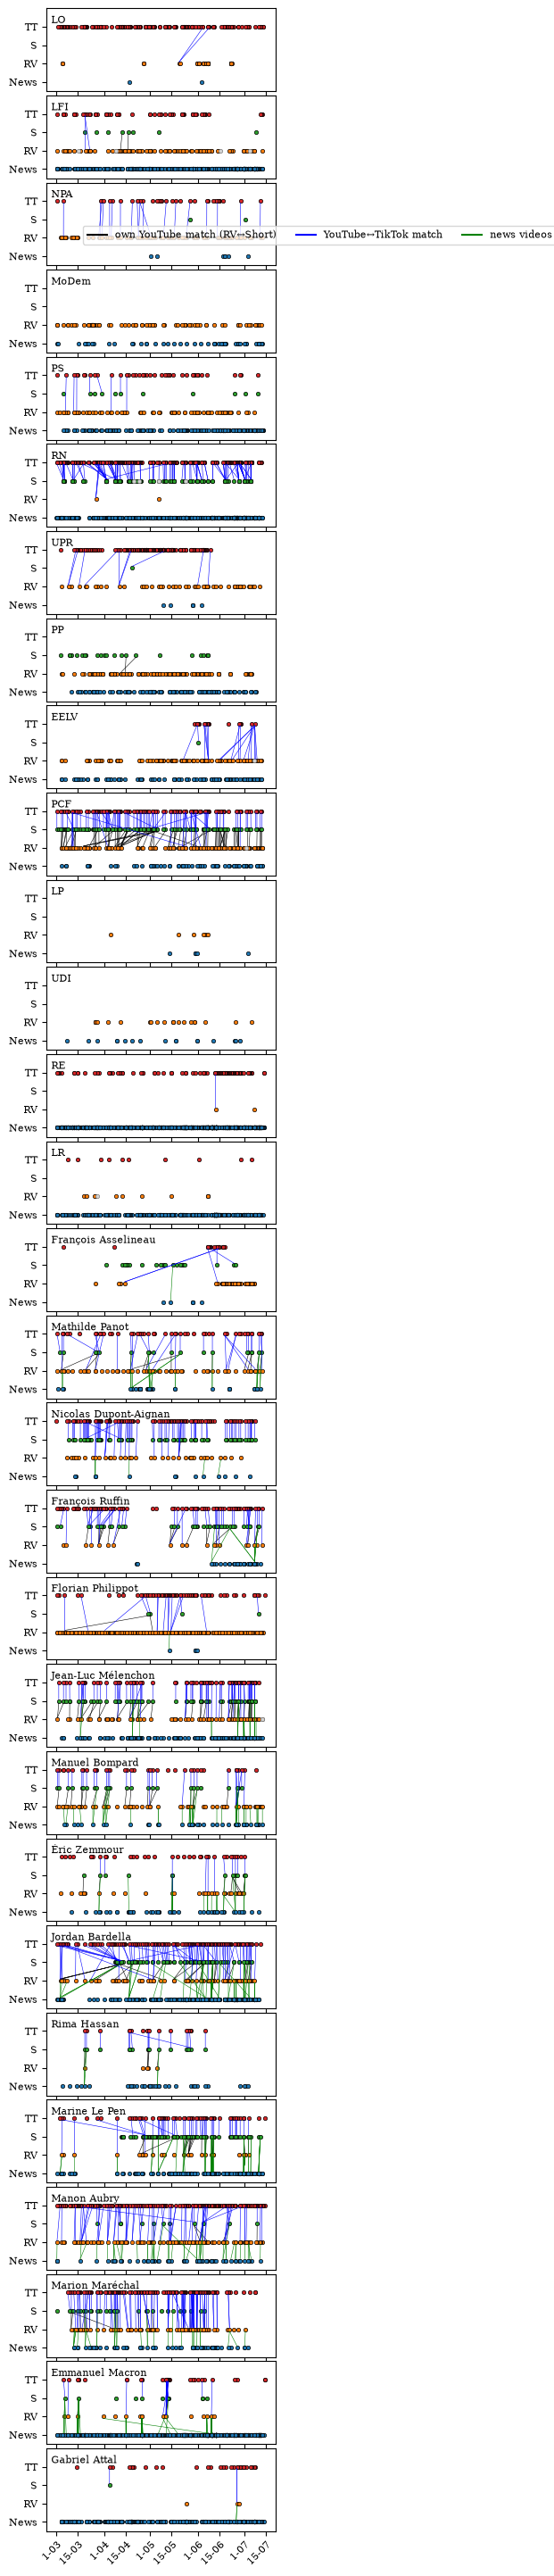

In [59]:
plot_upload_patterns_news_pp(df_yt_all = yt_pp_videos_2024, df_tt_all = tt_pp_videos_2024,
                             df_news_all=yt_nm_videos_2024,
                             gs = gs_pp_only, gs_news=gs_diff, channels_list=None,
                             save_fig=None, parties_all_members=False,
                             news_flag_col=None)

# 8. Negative-Delay Sanity Check

When a cross-channel match has the politician video posted *before* the news video, this may indicate the news channel reposted the politician (rather than the reverse). Export those cases for manual inspection.

In [60]:
from datetime import timedelta

source_news_df = []
for i, name_abbr in enumerate(yt_pp_standard_names):
    df = videos_yt_df[
        (videos_yt_df.name_abbr == name_abbr) &
        (~videos_yt_df.videoId.isin(all_transcripts[all_transcripts.transcript.isna()]['videoId']))
    ][['name_abbr', 'videoId', 'isShort', 'publishedAt']].copy()
    if len(df) == 0:
        continue
    df['publishedAt'] = df['publishedAt'].dt.tz_localize(None)

    df['source_videoId_news'] = df.apply(get_source, name_abbr=name_abbr, gs=gs_diff, axis=1)

    df.loc[df['source_videoId_news'] != '', 'source_vidnews_publishedAt'] = (
        df.loc[df['source_videoId_news'] != '', 'source_videoId_news'].apply(
            lambda x: all_videos[all_videos.videoId == x]['publishedAt'].values[0]
            if len(all_videos[all_videos.videoId == x]) > 0 else None
        )
    )

    df.loc[df['source_videoId_news'] != '', 'time_before_repost_news'] = (
        df.loc[df['source_videoId_news'] != '', 'publishedAt'] -
        df.loc[df['source_videoId_news'] != '', 'source_vidnews_publishedAt']
    )
    source_news_df.append(df[~df['source_vidnews_publishedAt'].isna()])

source_news_df = pd.concat(source_news_df)


NameError: name 'videos_yt_df' is not defined

In [ ]:
source_news_df[source_news_df.time_before_repost_news < timedelta(0)]

```python
# Export video pairs with negative repost delay for manual review
(
    source_news_df[source_news_df.time_before_repost_news < timedelta(0)]
    [['videoId', 'source_videoId_news']]
    .map(lambda x: f'www.youtube.com/watch?v={x}')
    .to_excel('data/transcripts/negative_repost_times.xlsx')
)
